<a href="https://colab.research.google.com/github/GiannaReyes/eel4660-spring2026-python-basics-python-basics-1/blob/main/Goosebot_Detection_Gianna_Reyes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/112.6 GB disk)


# Change path to your yaml file

In [3]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.pt")

# Train the model
results = model.train(data="/content/drive/MyDrive/GooseBot.v2i.yolov11/data.yaml", epochs=100, imgsz=640)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GooseBot.v2i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list containing mAP50-95 for each category

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,712 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 26.2±4.0 MB/s, size: 34.6 KB)
val: Scanning /content/drive/MyDrive/GooseBot.v2i.yolov11/valid/labels.cache... 9 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9/9 2.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.6it/s 0.4s
                   all          9        137      0.605      0.498      0.518      0.319
                  duck          5         43      0.897      0.953      0.966      0.679
        l_intersection          3          3      0.164        0.4      0.195       0.11
                 mouse          5          5          1          0      0.365      0.223
               redline          6         17      0.618      0.765      0.704      0.373
        t_intersection          3

array([    0.67914,     0.11042,     0.22309,      0.3734,     0.31919,     0.17339,     0.39804,     0.27688])

# Change path to your test images folder

In [5]:
model.predict('/content/drive/MyDrive/GooseBot.v2i.yolov11/test/images', save=True)


image 1/4 /content/drive/MyDrive/GooseBot.v2i.yolov11/test/images/17_jpg.rf.8f3cde96671097eda8cffa0546f25fa1.jpg: 640x640 4 redlines, 3 whitelines, 1 yellowline, 8.3ms
image 2/4 /content/drive/MyDrive/GooseBot.v2i.yolov11/test/images/22_jpg.rf.8f81e3559392b4b27972c4d764bd16fa.jpg: 640x640 9 ducks, 1 l_intersection, 3 redlines, 6 whitelines, 5 yellowlines, 18.3ms
image 3/4 /content/drive/MyDrive/GooseBot.v2i.yolov11/test/images/31_jpg.rf.d65c6d11d36bae39806b07ecda09fbcd.jpg: 640x640 8 ducks, 3 redlines, 7 whitelines, 3 yellowlines, 8.9ms
image 4/4 /content/drive/MyDrive/GooseBot.v2i.yolov11/test/images/32_jpg.rf.a30a546ef0ab3f2d5a04d1e508e8abb1.jpg: 640x640 7 ducks, 1 l_intersection, 5 redlines, 6 whitelines, 7 yellowlines, 11.8ms
Speed: 3.5ms preprocess, 11.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'duck', 1: 'l_intersection', 2: 'mouse', 3: 'redline', 4: 'stopsign', 5: 't_intersection', 6: 'whiteline', 7: 'yellowline'}
 obb: None
 orig_img: array([[[133, 107,  93],
         [134, 108,  94],
         [133, 109,  97],
         ...,
         [173, 164, 144],
         [125, 118,  99],
         [ 75,  68,  49]],
 
        [[133, 107,  93],
         [132, 109,  94],
         [133, 110,  95],
         ...,
         [169, 160, 140],
         [132, 125, 106],
         [ 95,  88,  69]],
 
        [[130, 107,  91],
         [129, 109,  92],
         [130, 110,  93],
         ...,
         [166, 157, 137],
         [149, 142, 123],
         [135, 127, 110]],
 
        ...,
 
        [[ 95,  93, 229],
         [ 97,  95, 231],
         [100,  98, 234],
         ...,
         [ 96,  84,  72],
         [ 97,  85,  73],
         [100,  88,  76]]

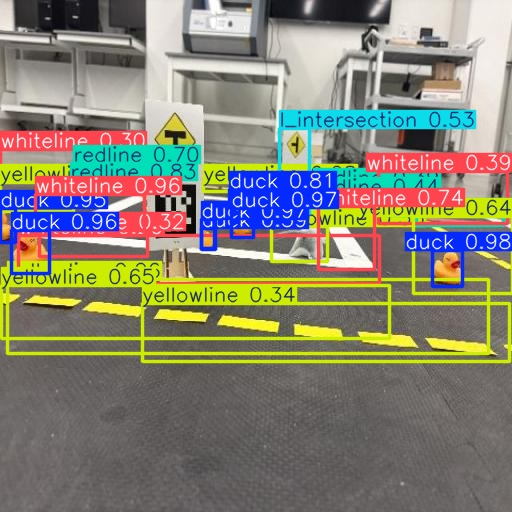

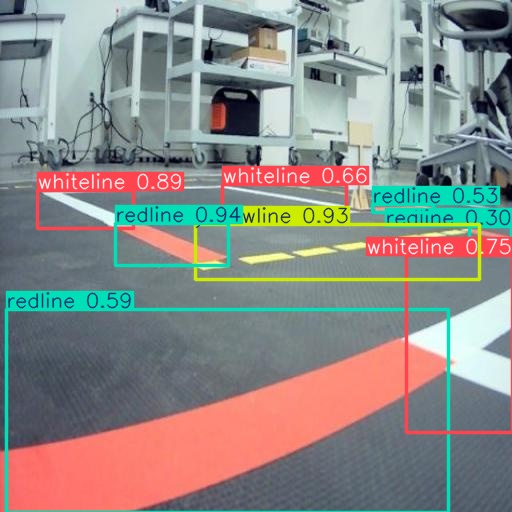

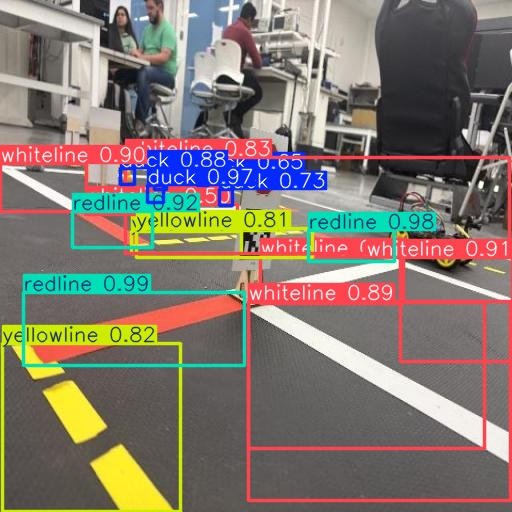

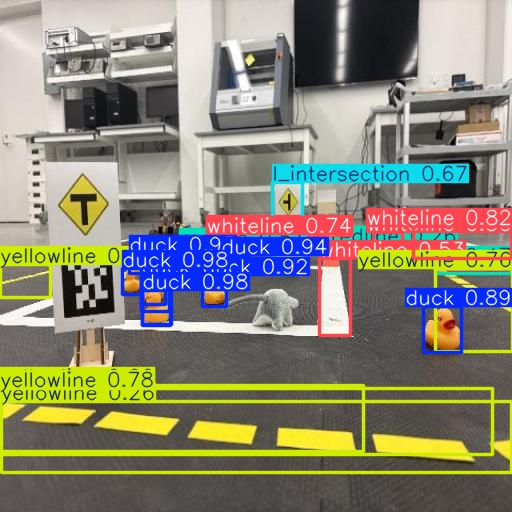

In [6]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/runs/detect/predict/*.jpg') + glob.glob('/content/runs/detect/predict/*.png'):
    display(Image(filename=image_path))

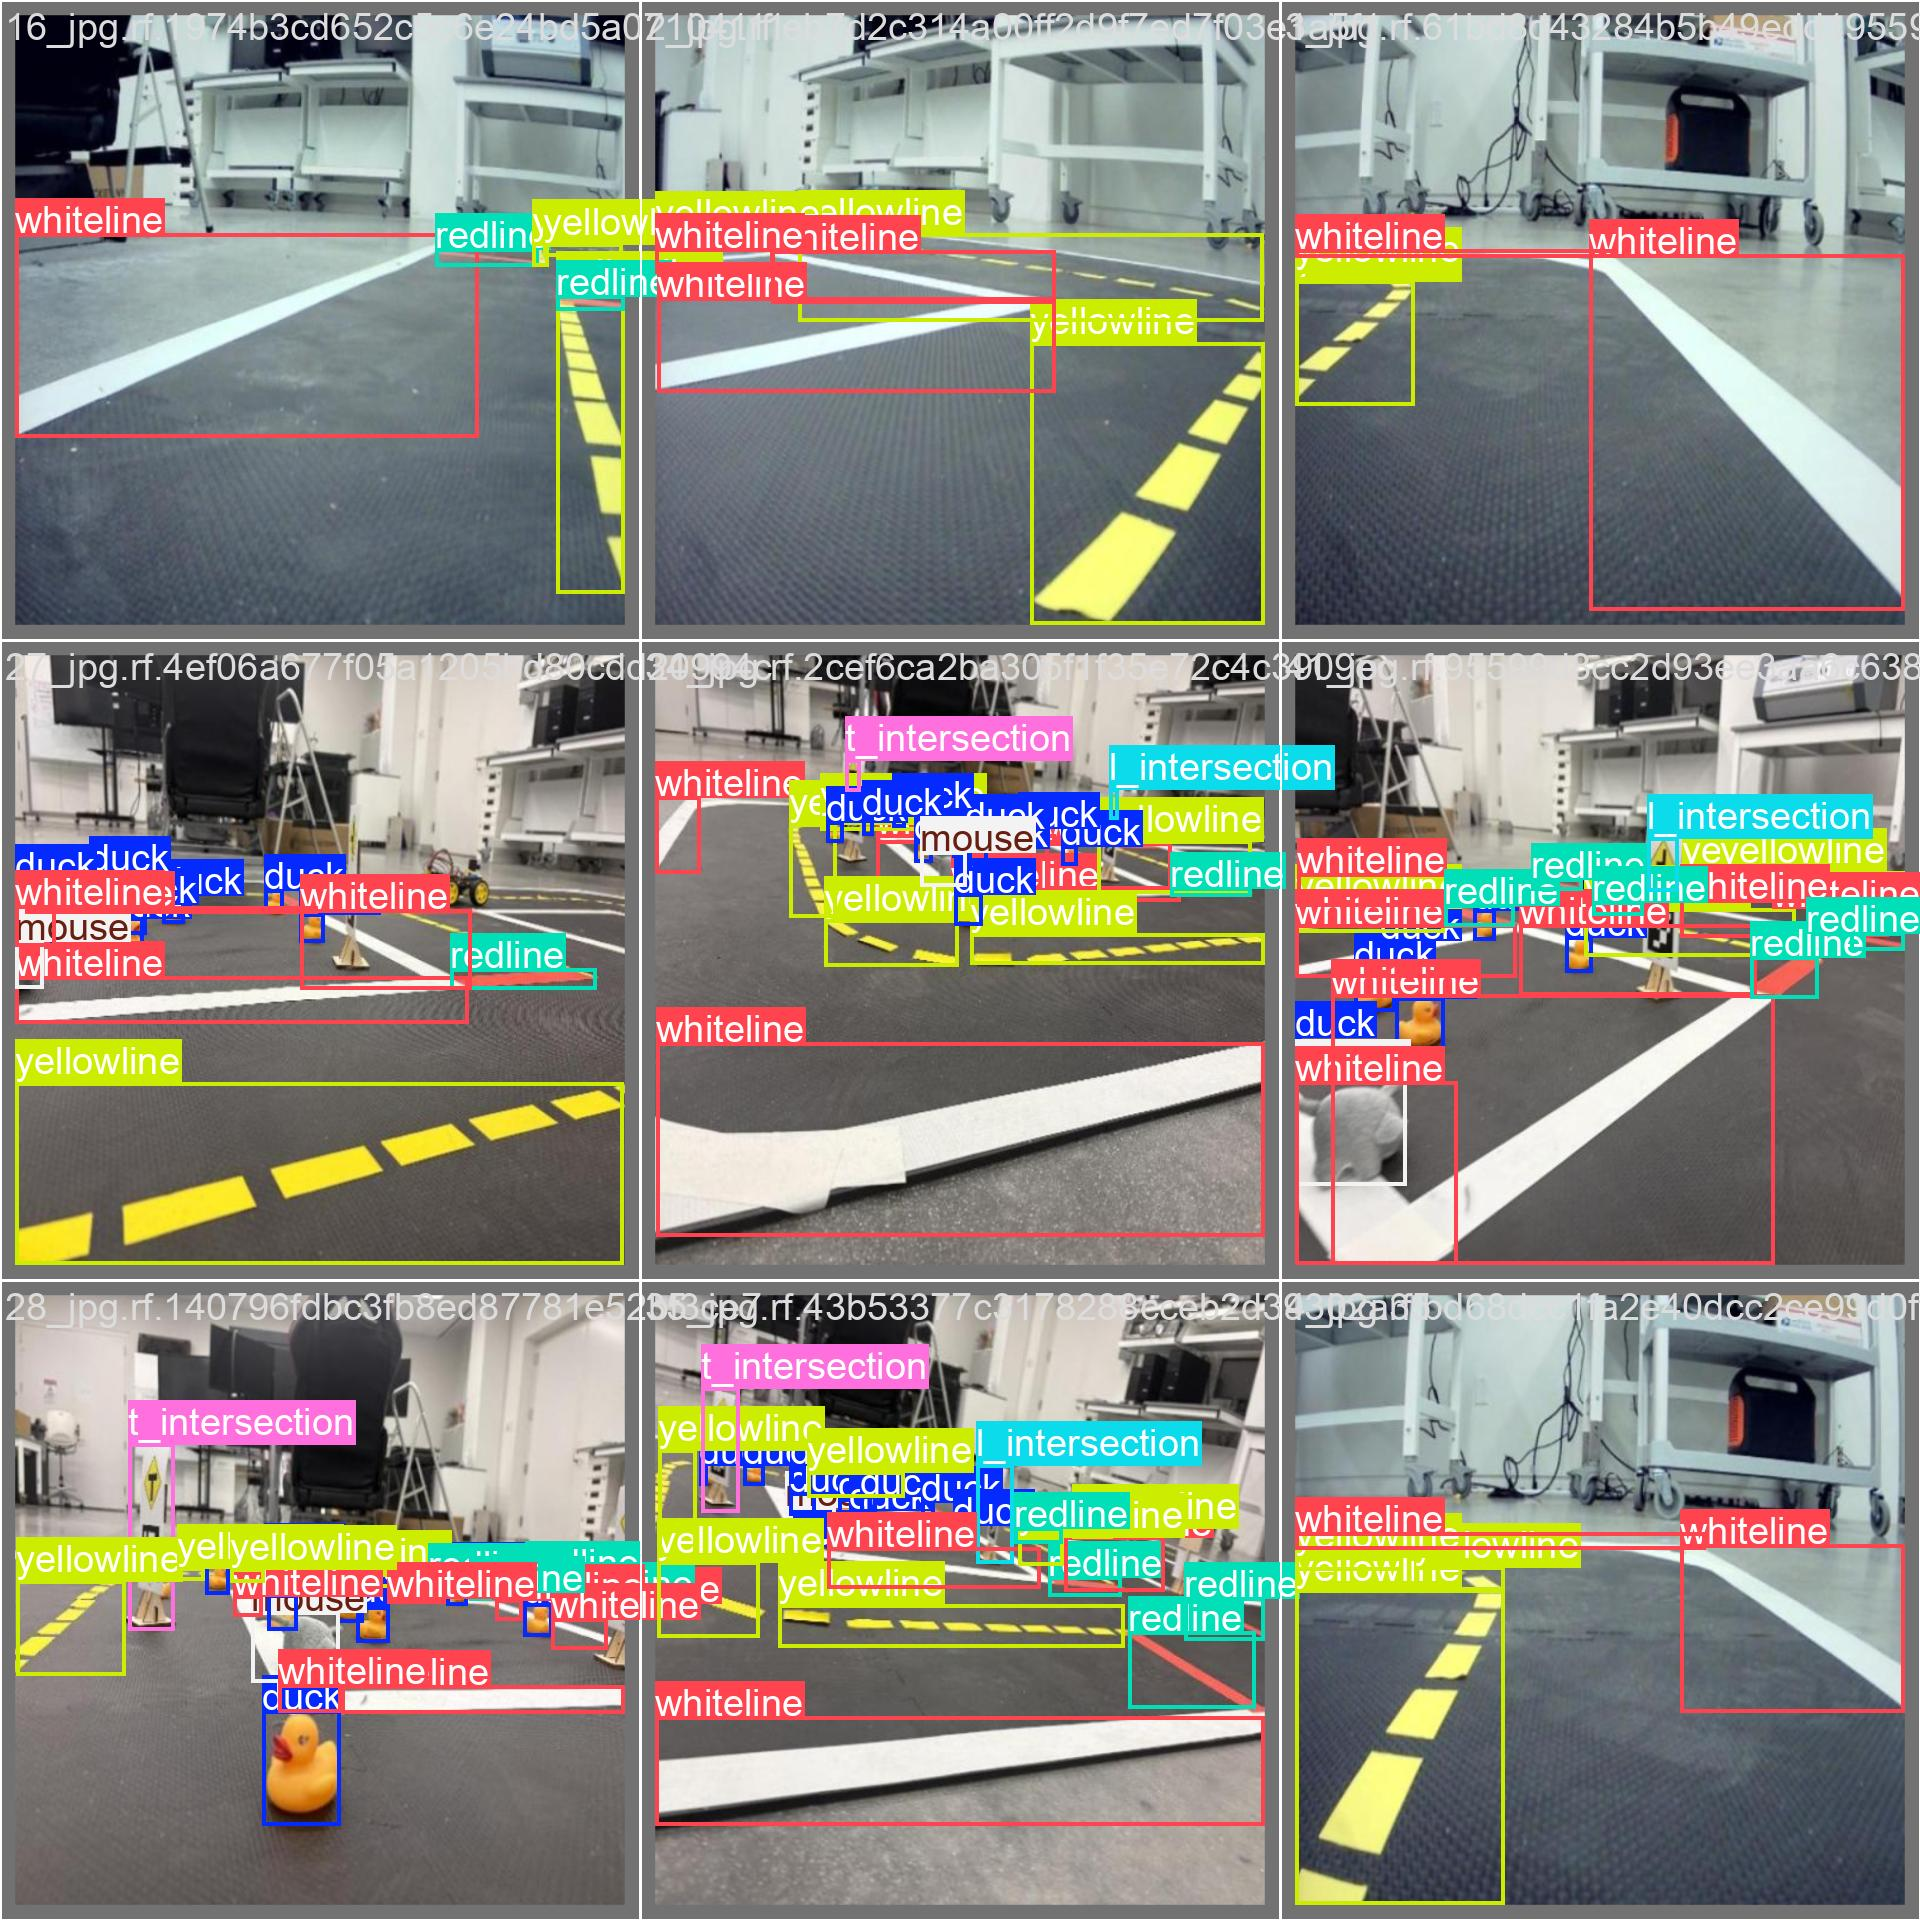

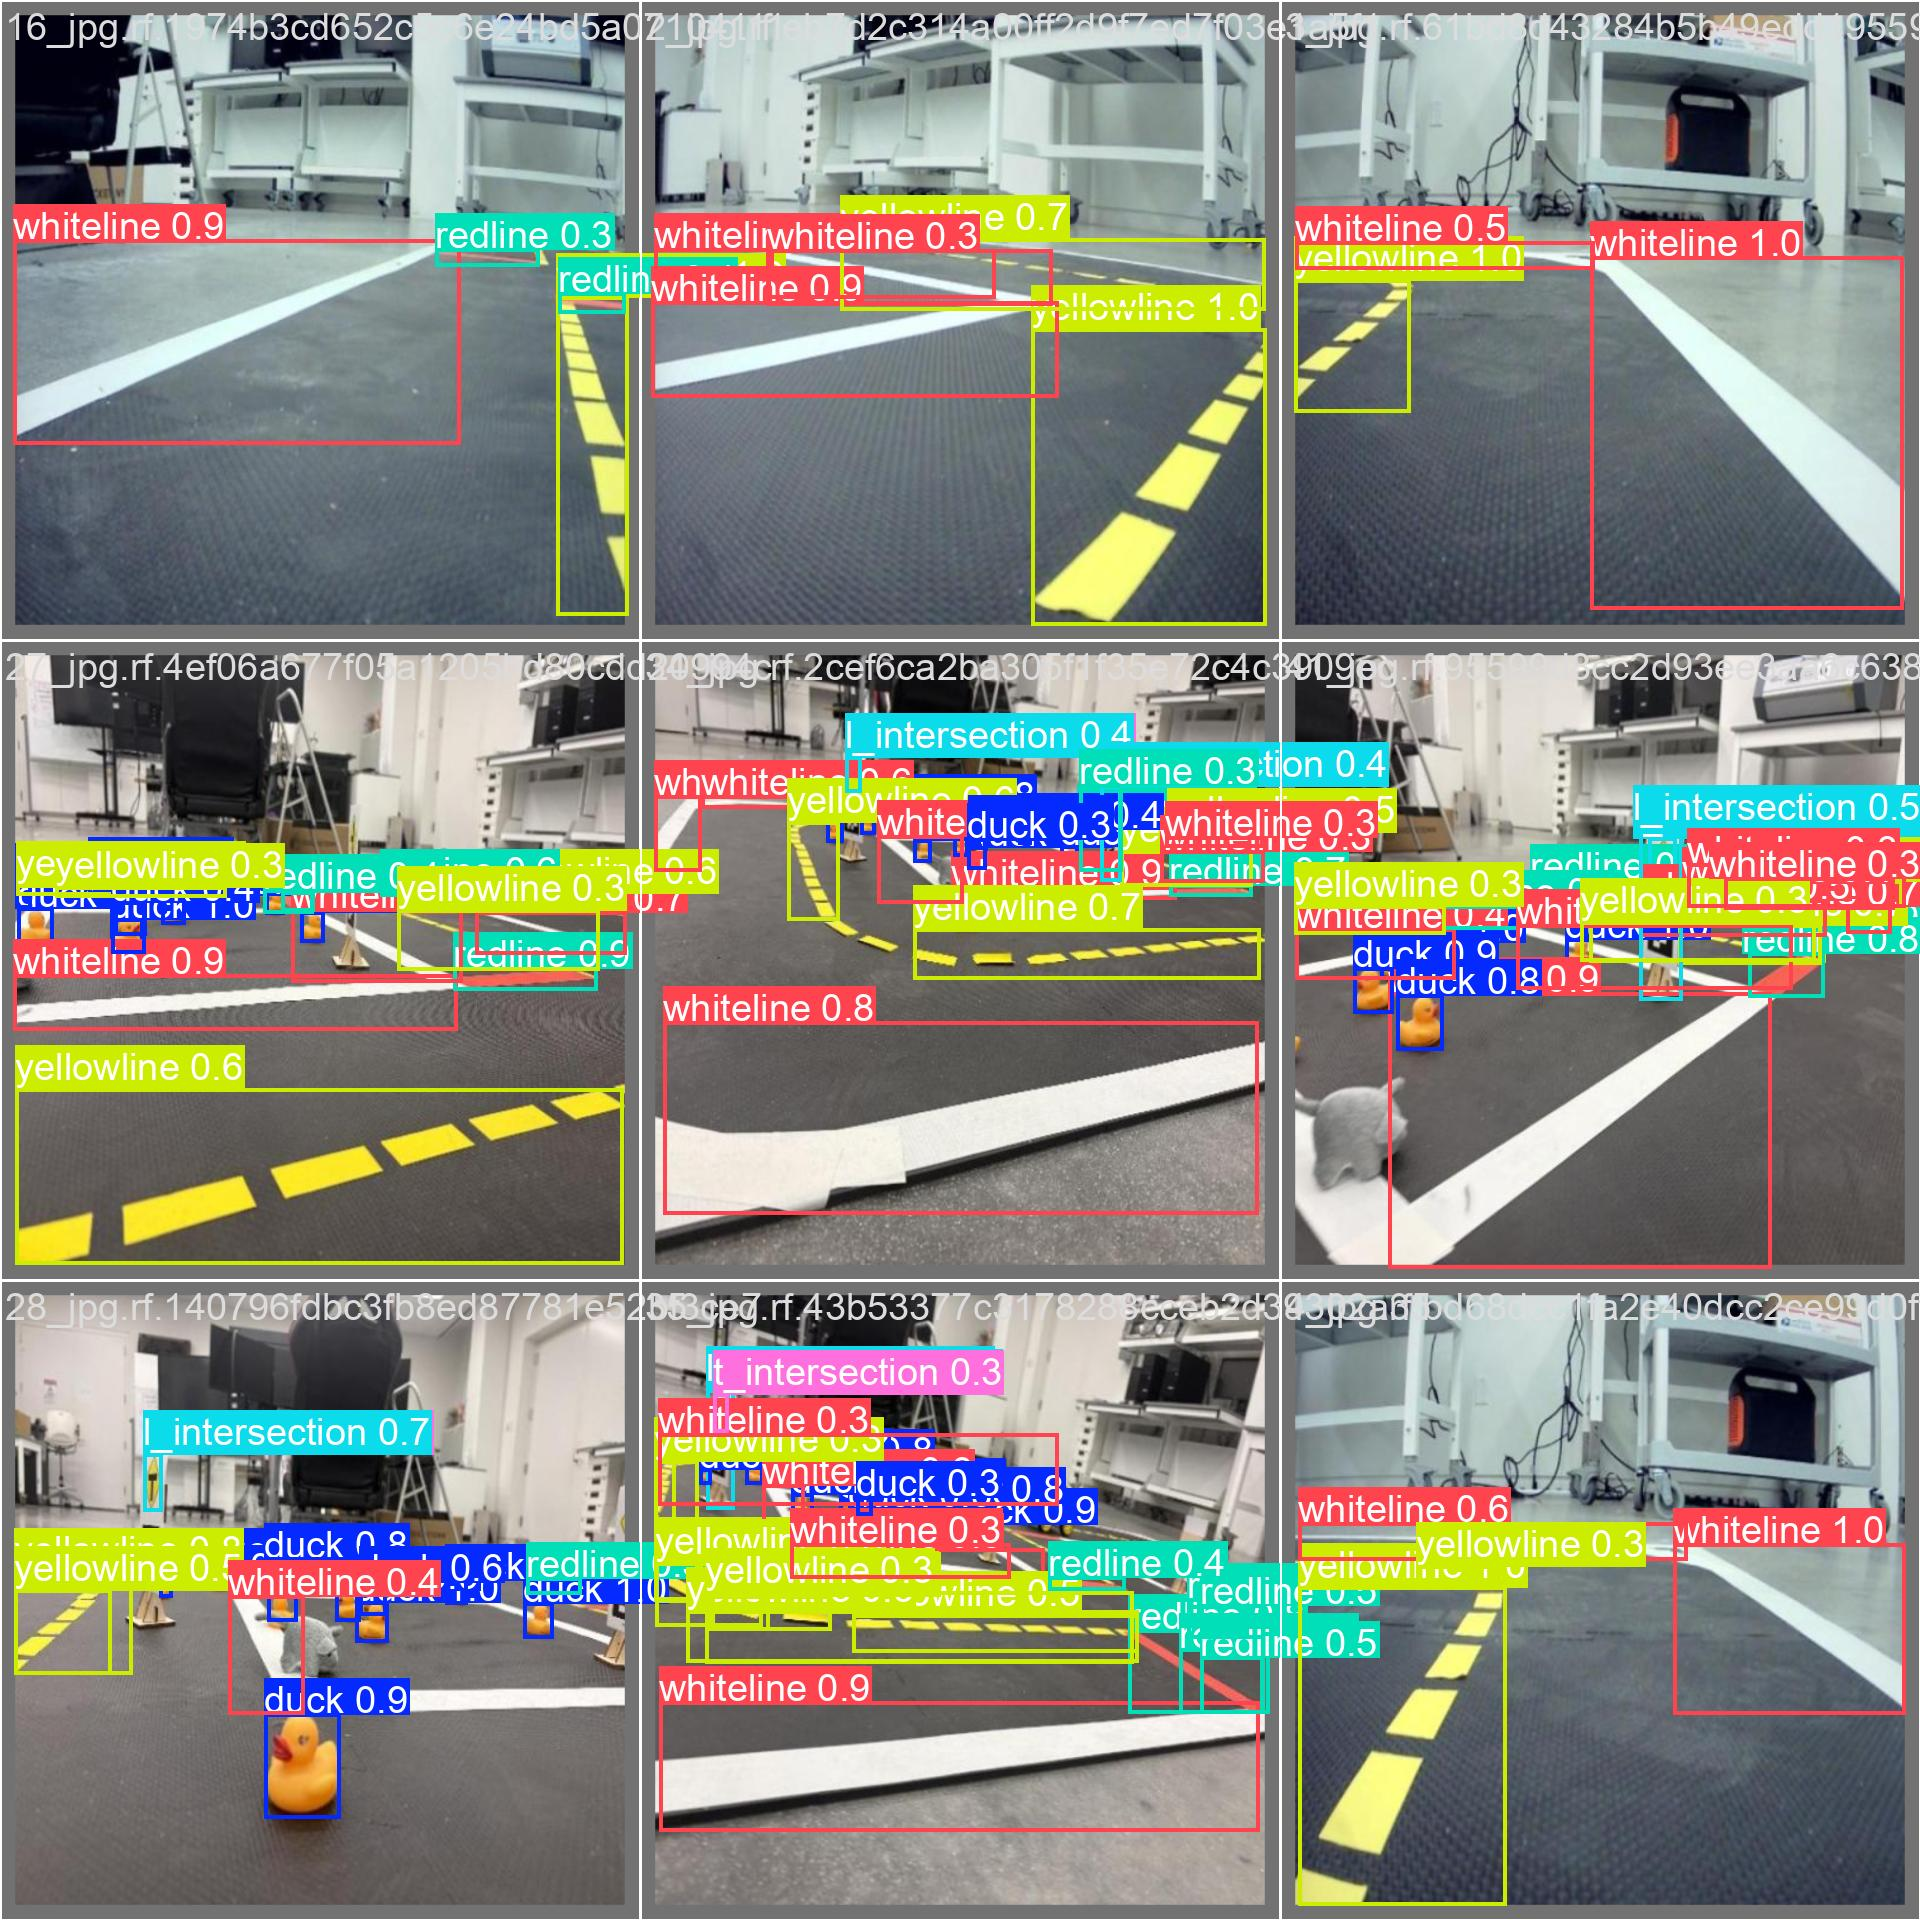

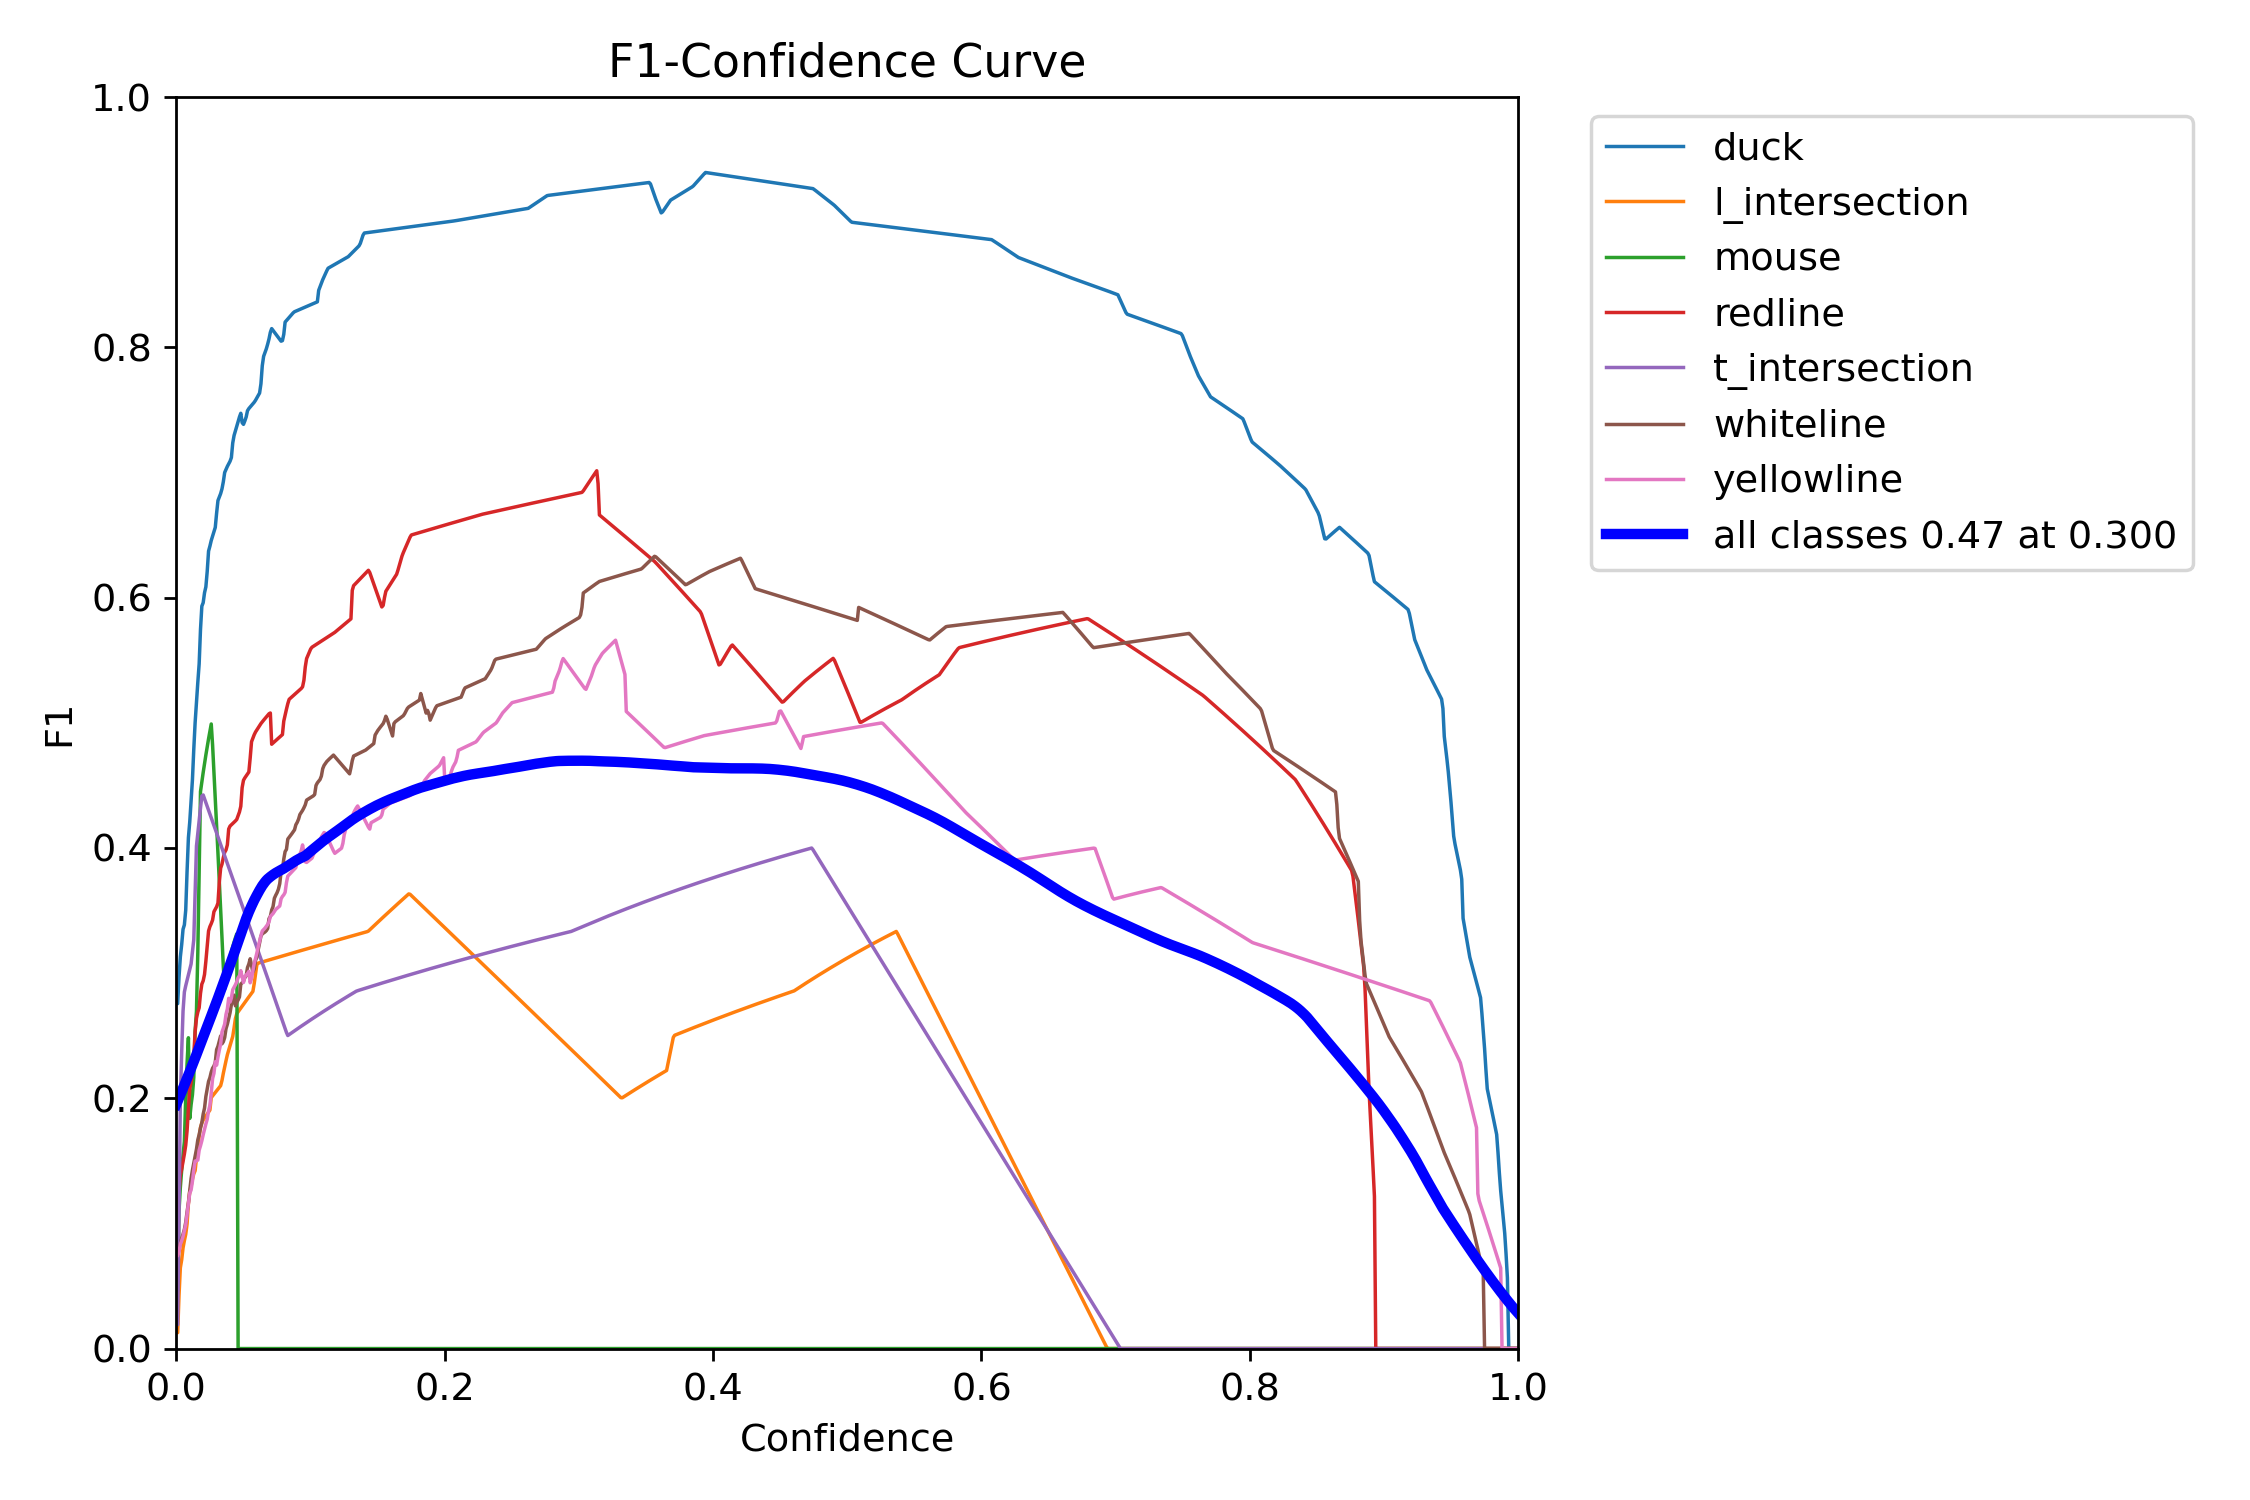

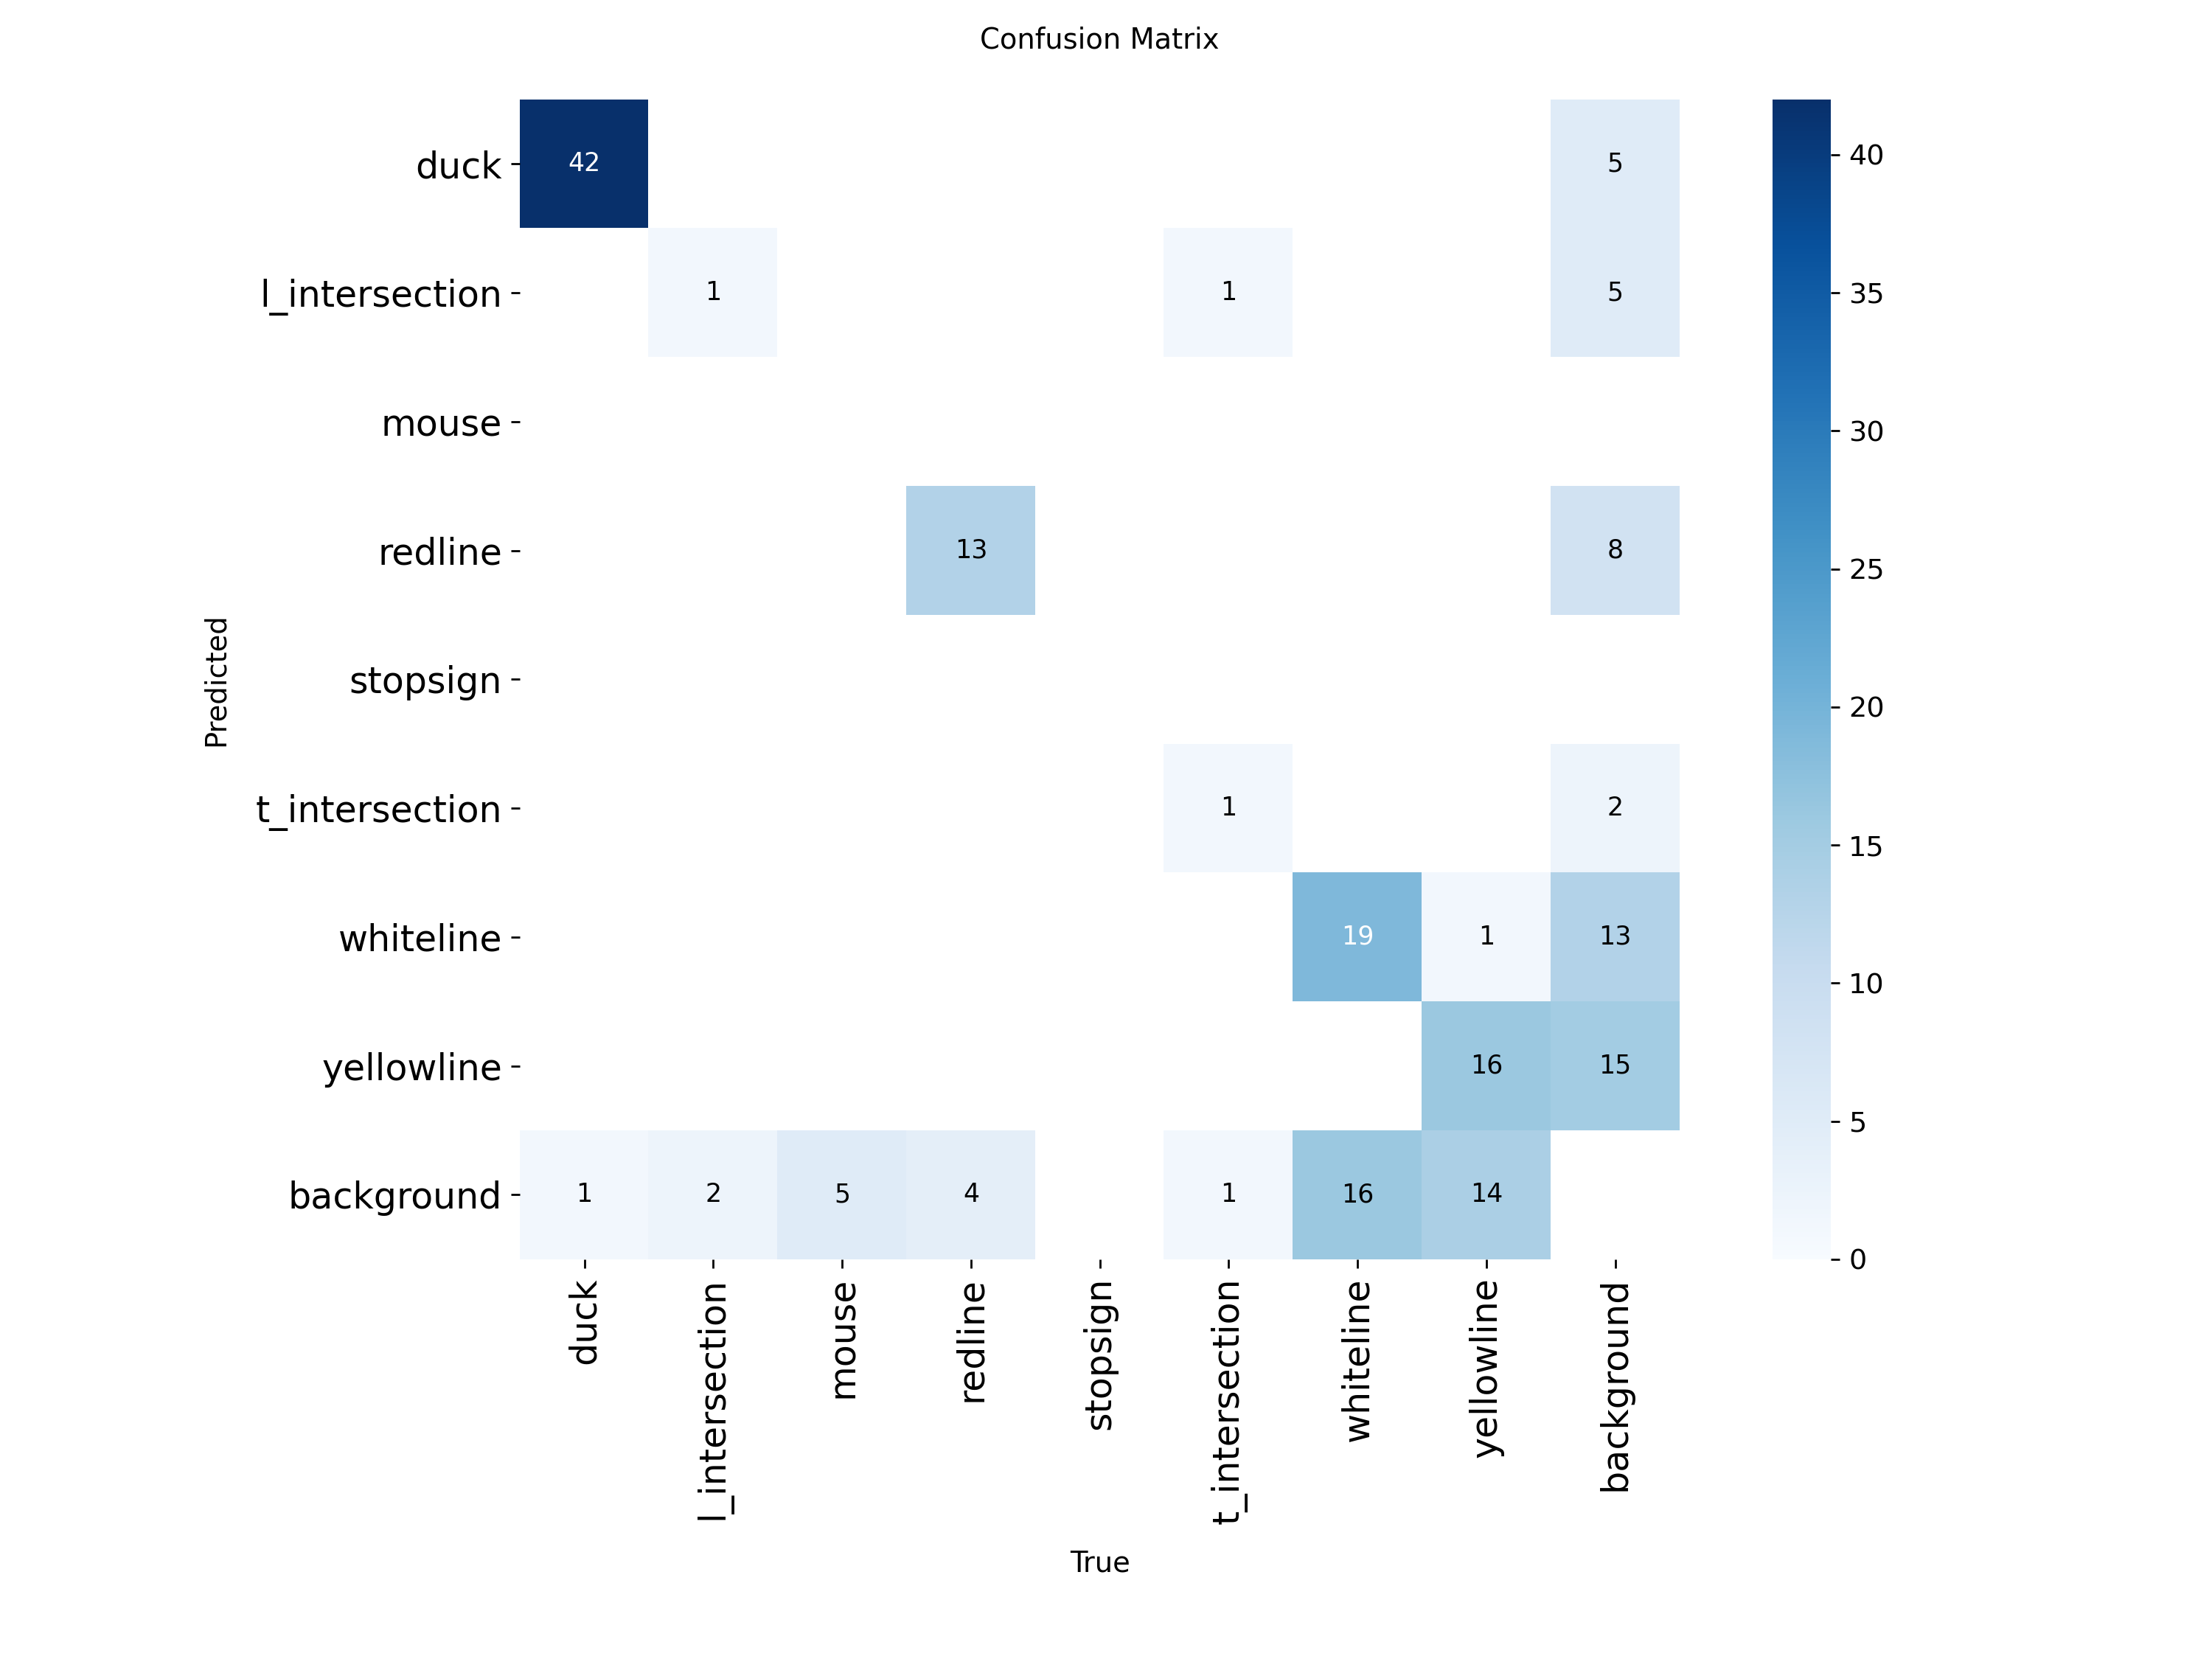

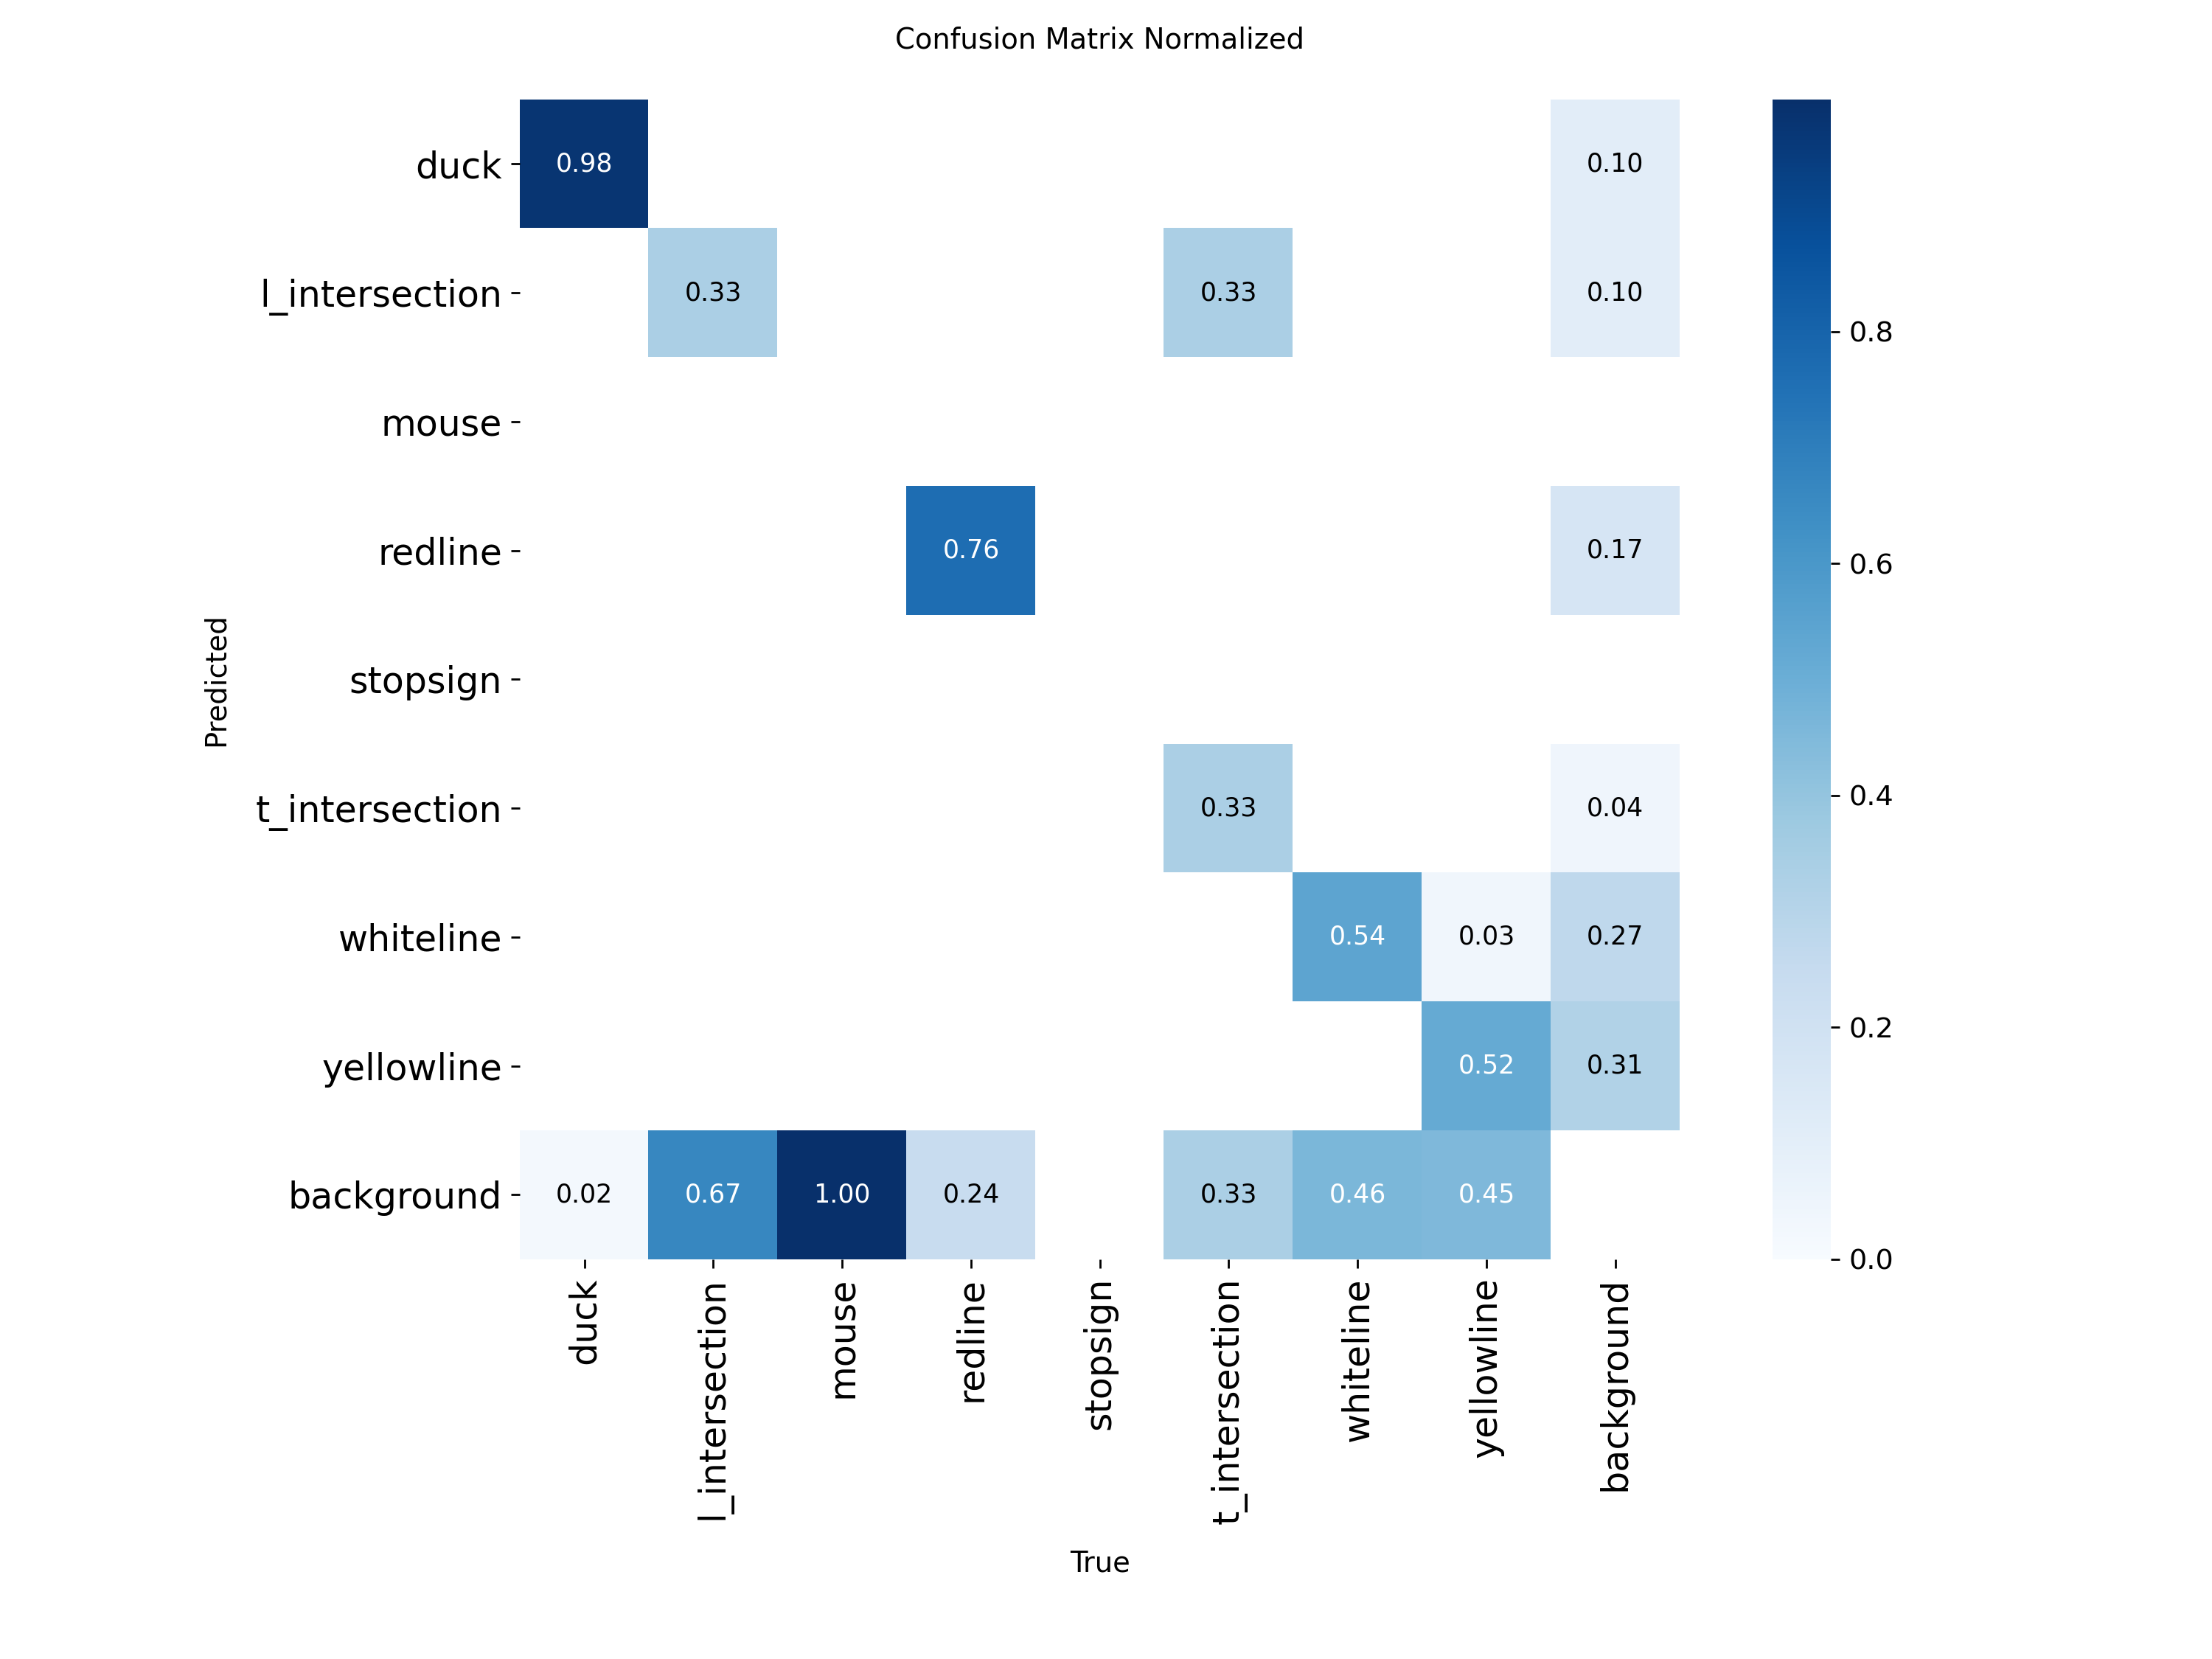

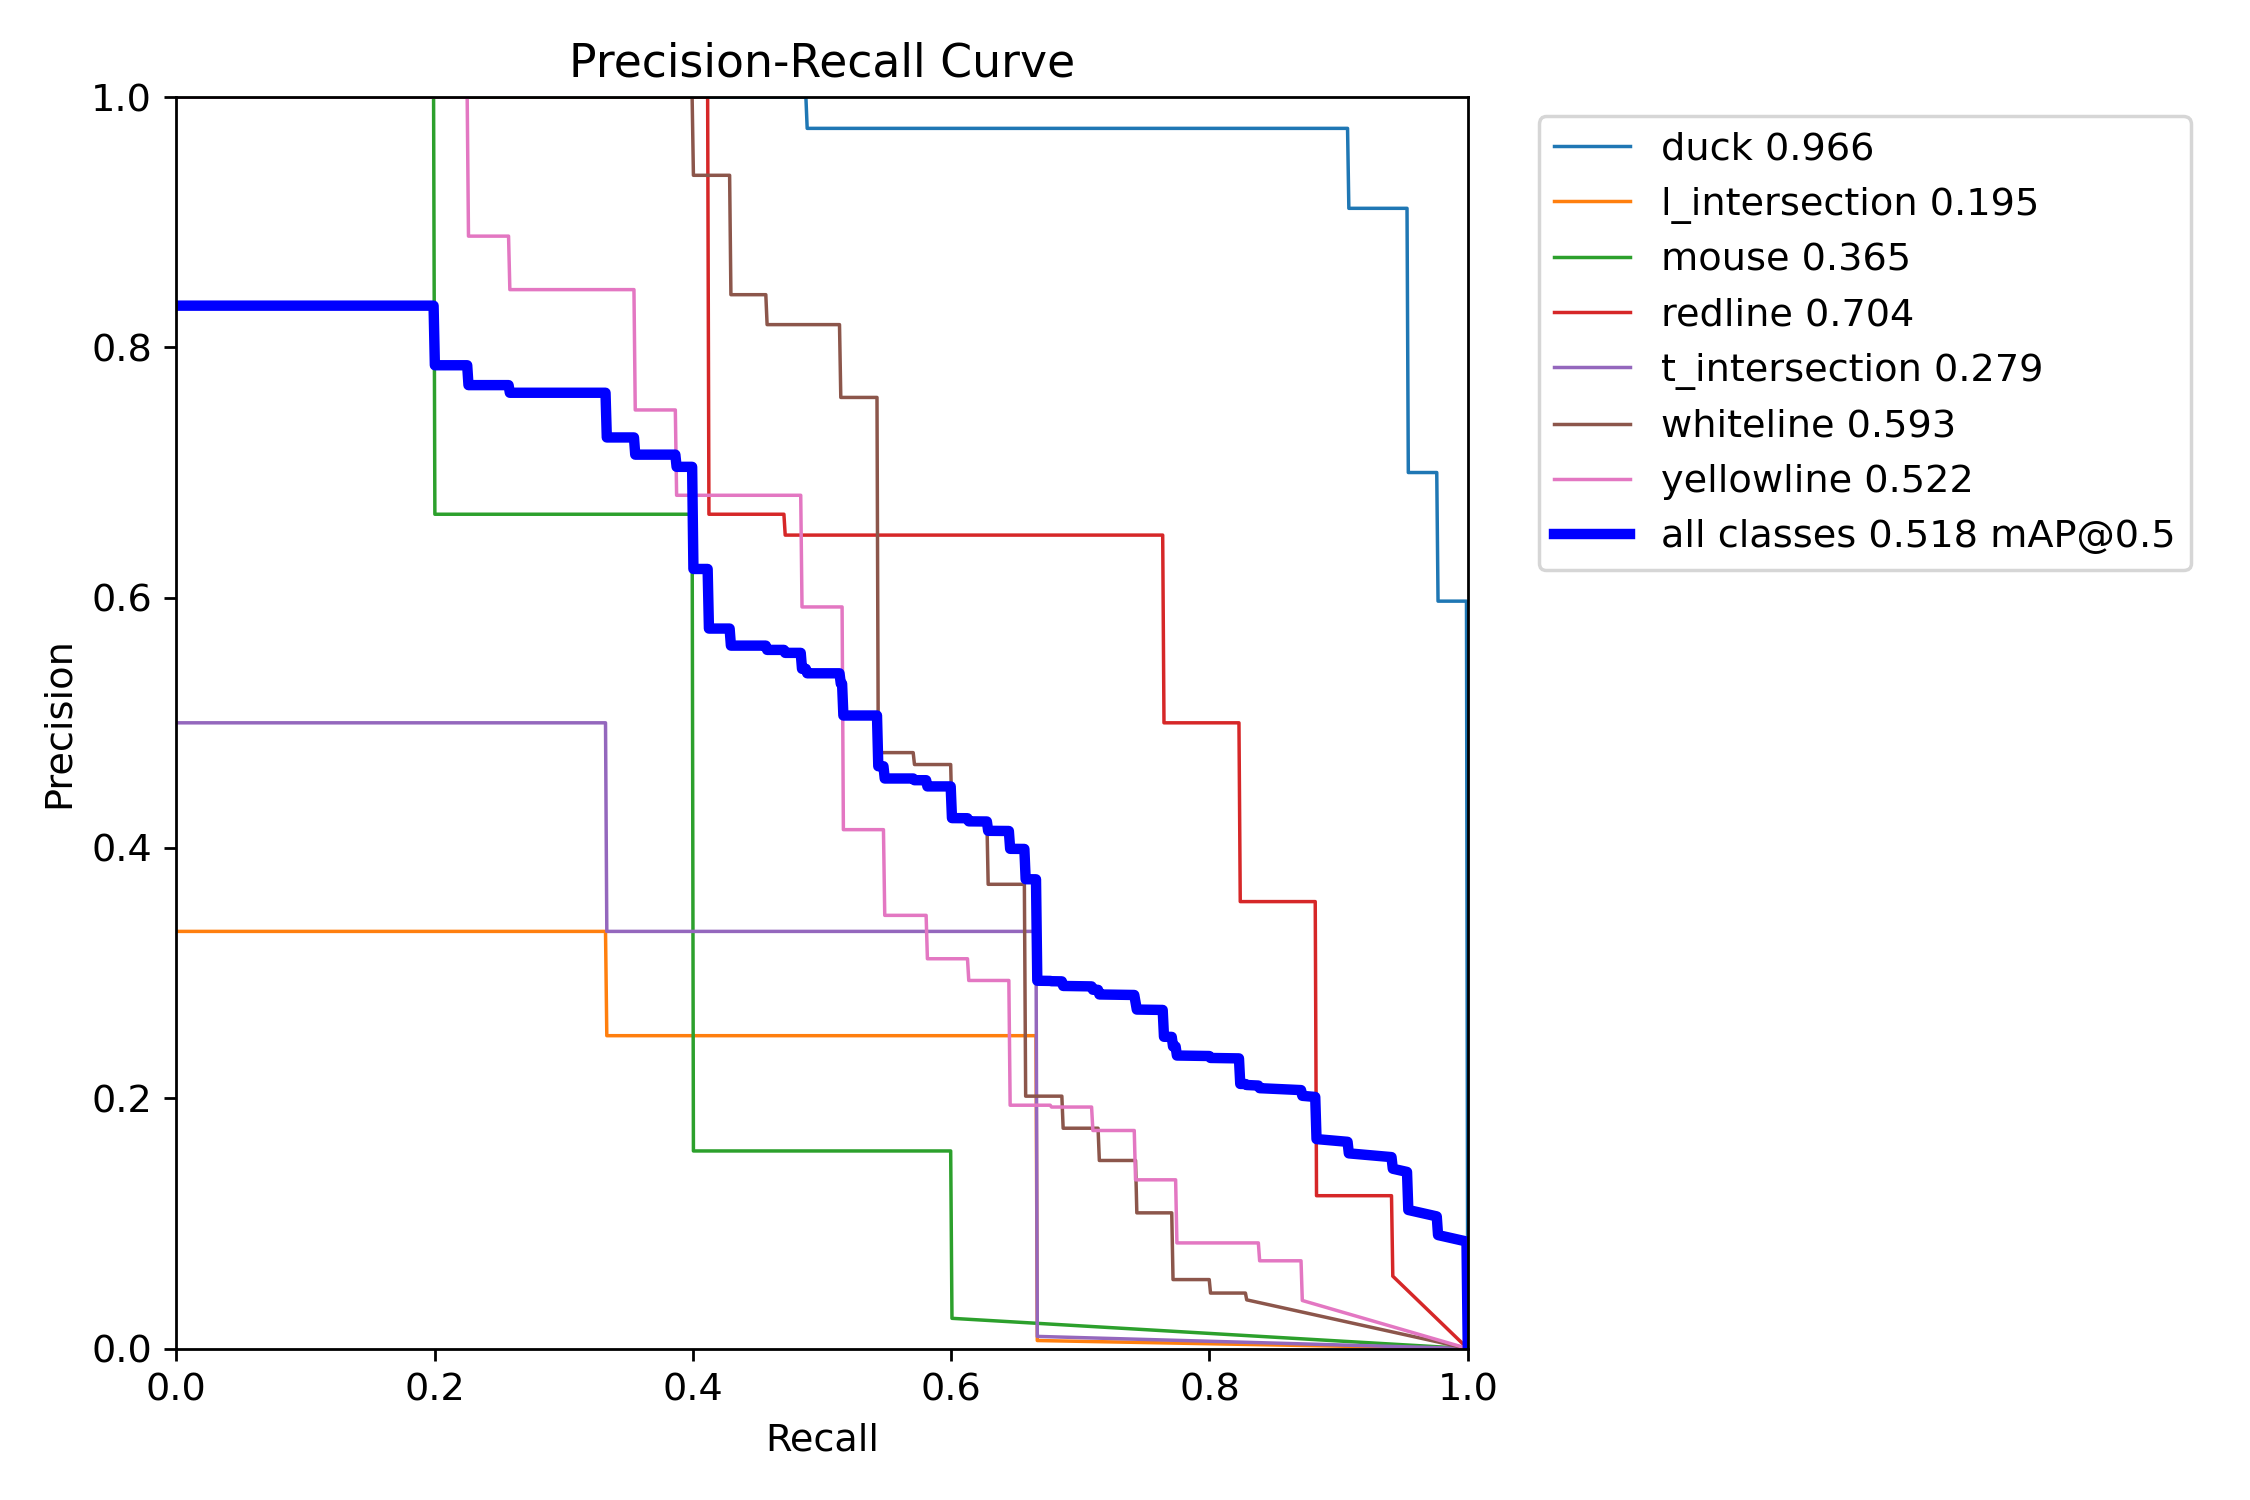

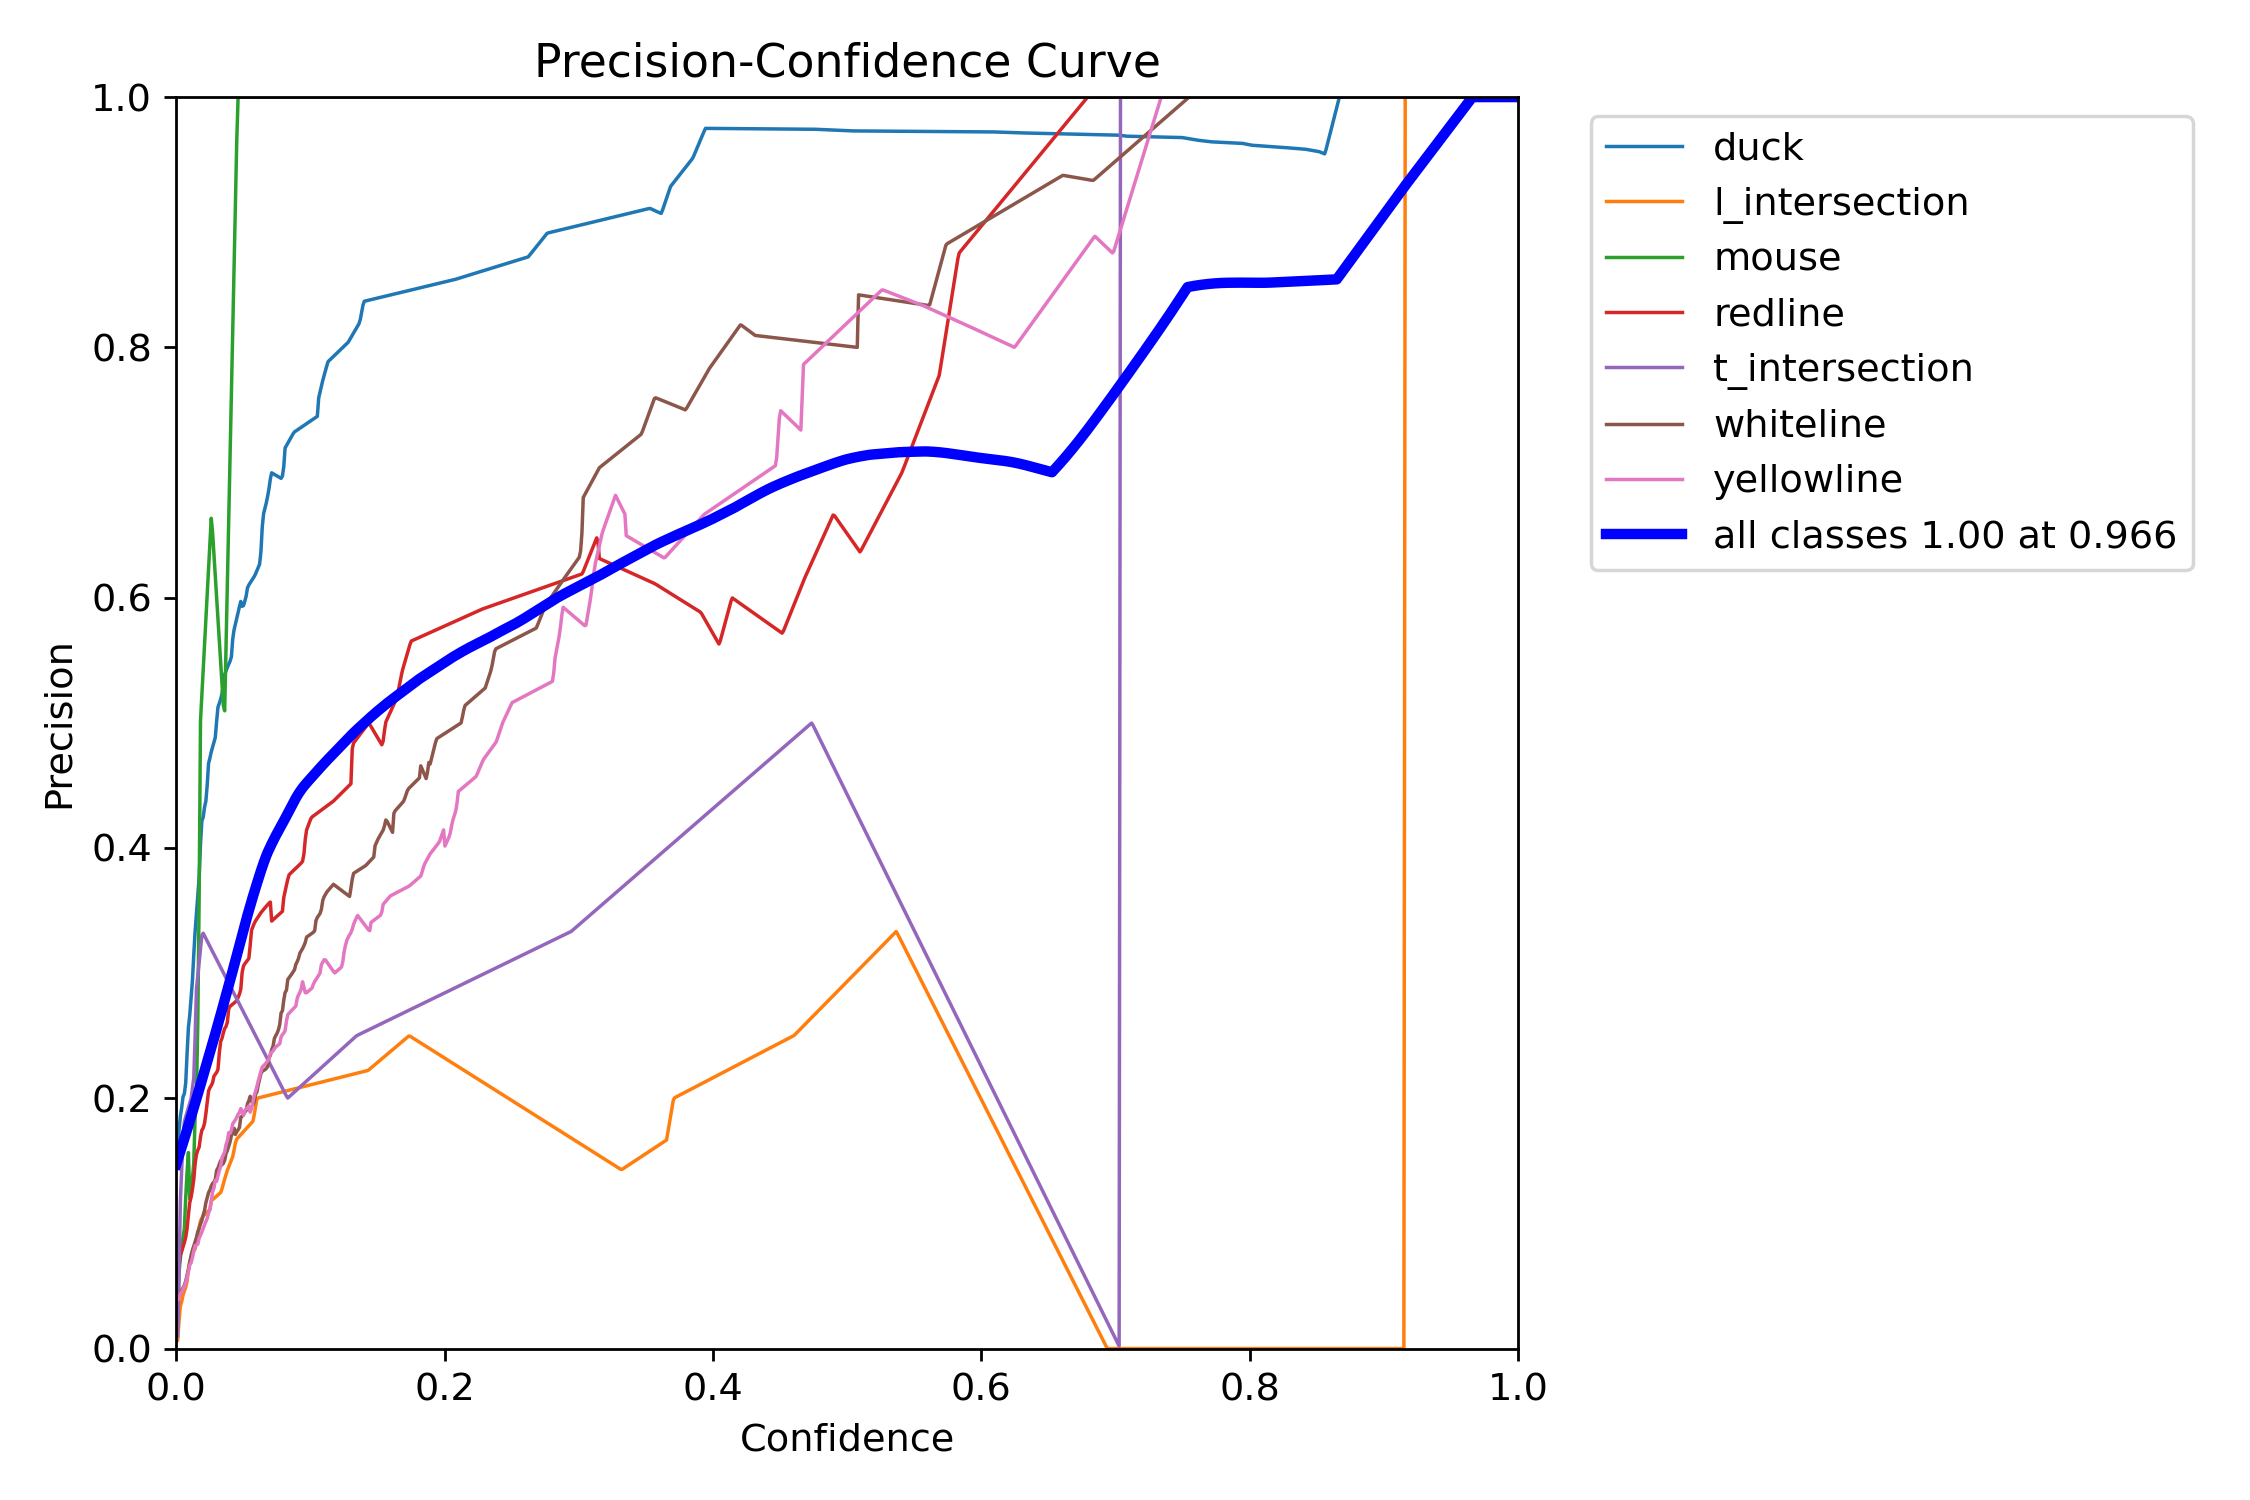

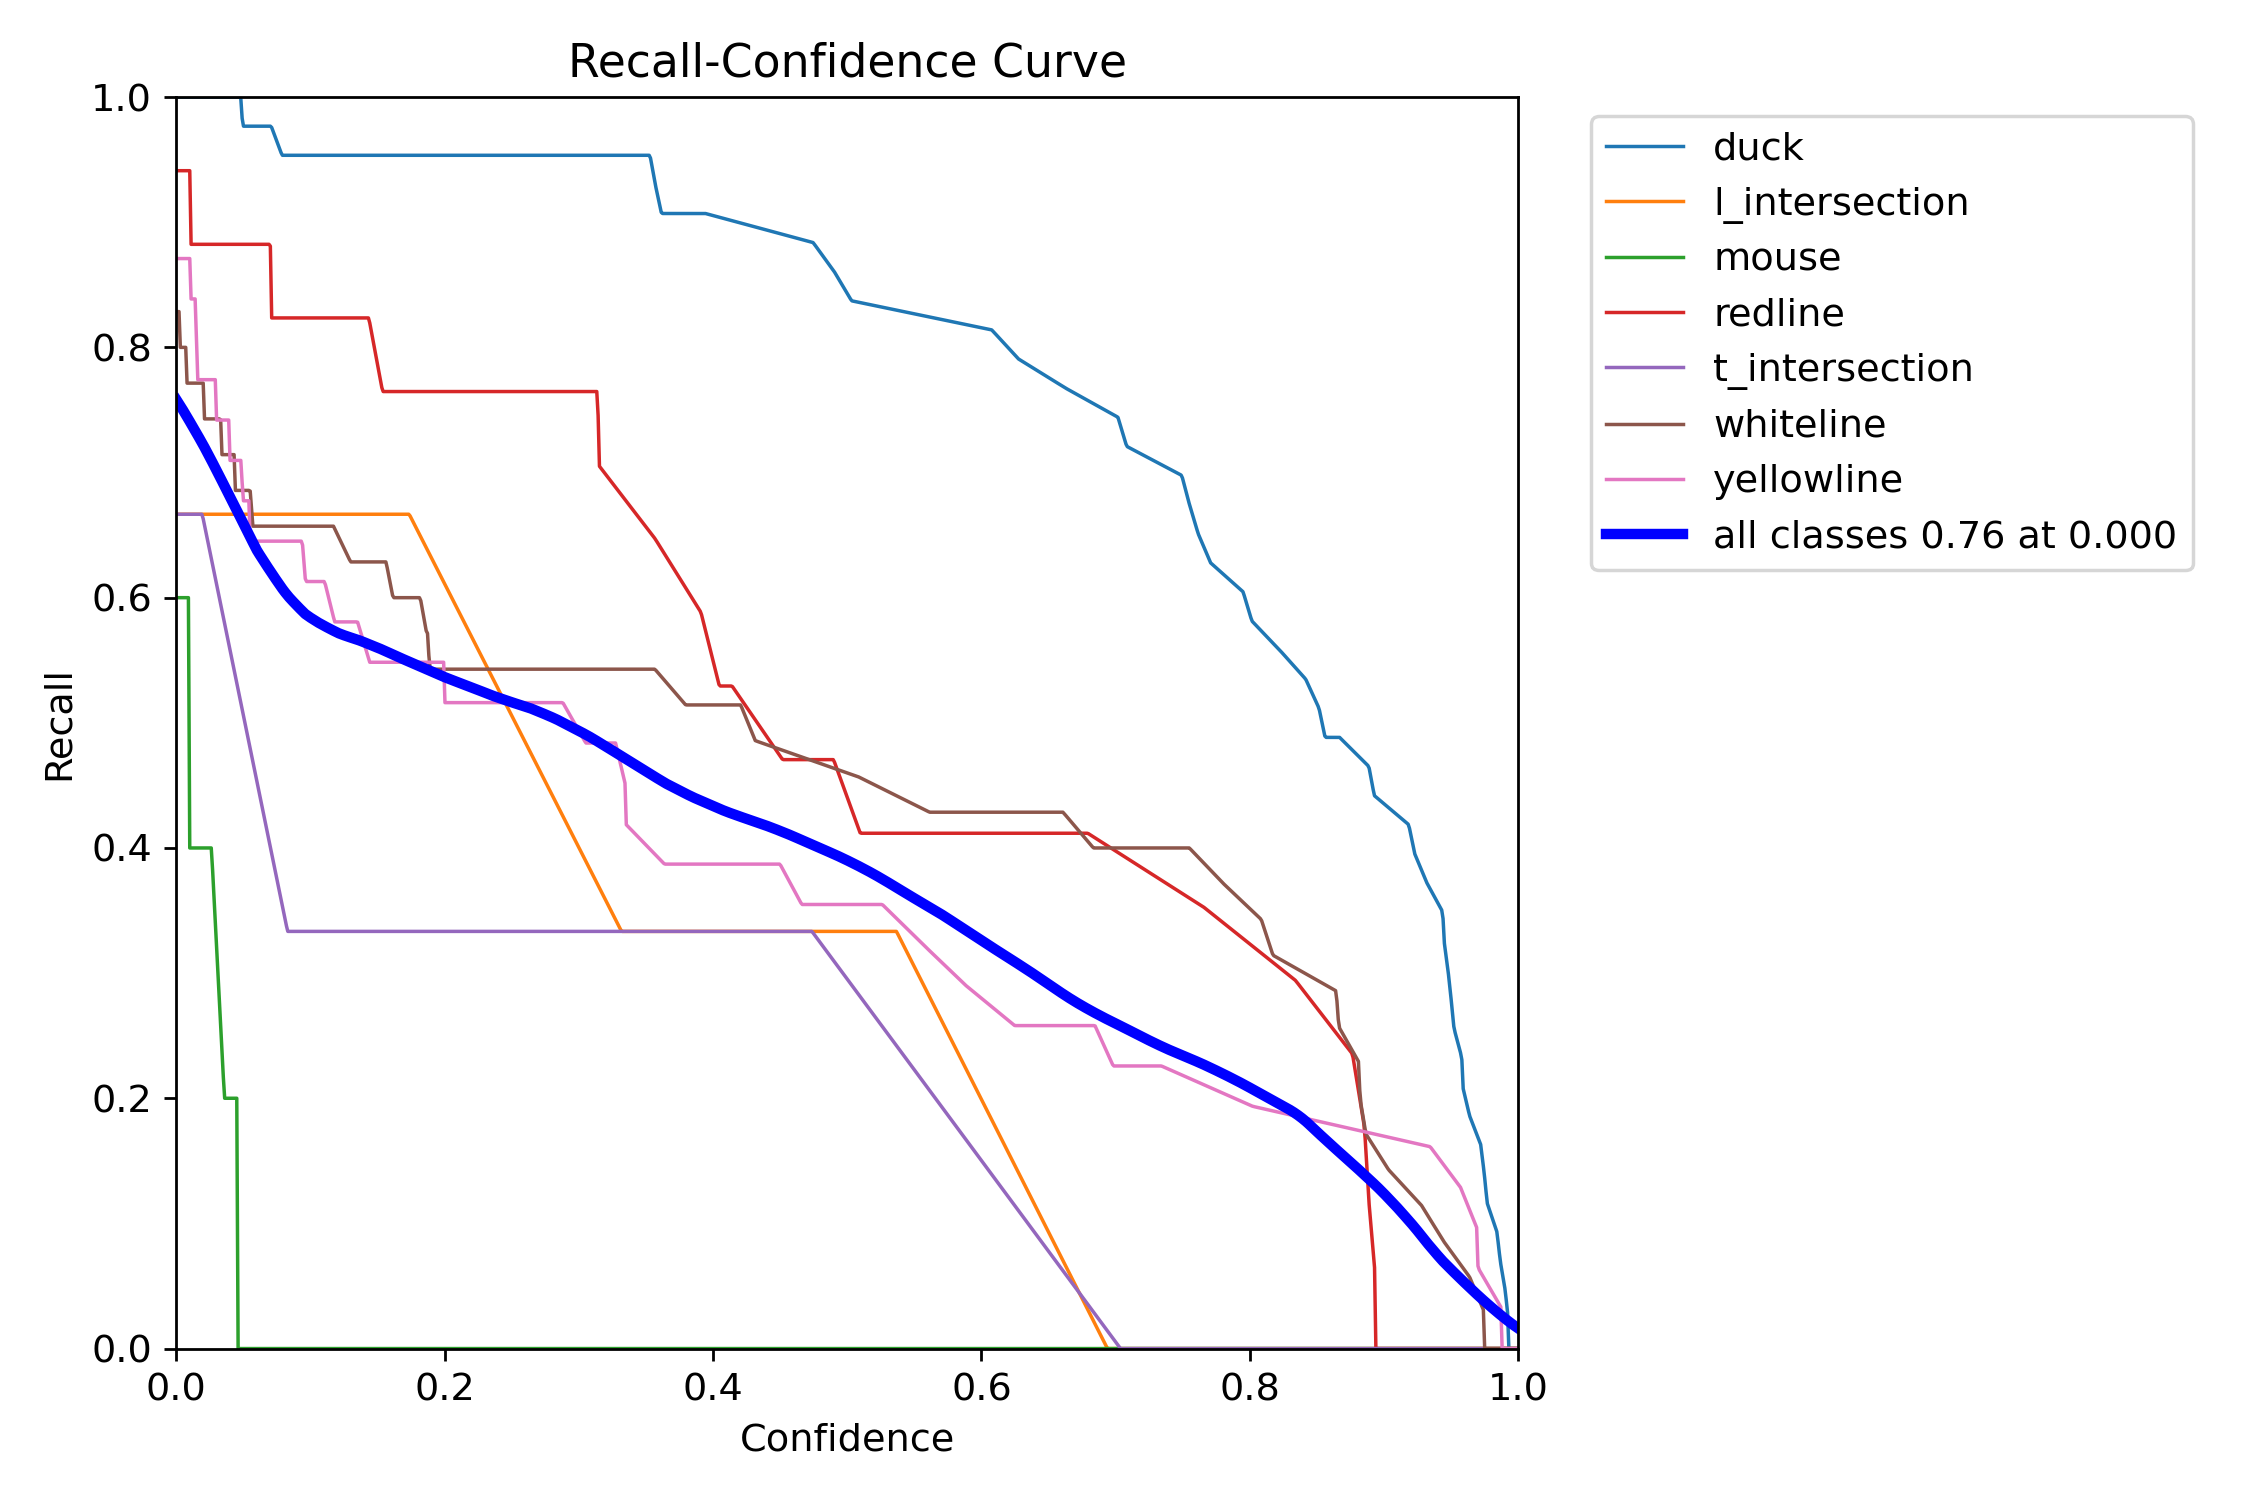

In [7]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/runs/detect/val/*.jpg') + glob.glob('/content/runs/detect/val/*.png'):
    display(Image(filename=image_path))

# Save model weight to a folder on Google Drive

In [11]:
import shutil
import os

drive_path = '/content/drive/MyDrive/goosebot'

source_dirs = [
    '/content/runs/detect/train',
    '/content/runs/detect/val',
    '/content/runs/detect/predict'
]

for source_dir in source_dirs:
    destination_dir = os.path.join(drive_path, os.path.basename(source_dir))
    if os.path.exists(destination_dir):
        print(f"Removing existing directory: {destination_dir}")
        shutil.rmtree(destination_dir)

    print(f"Copying {source_dir} to {destination_dir}")
    shutil.copytree(source_dir, destination_dir)
    print(f"Copied {source_dir} successfully.")

print("All results copied to Google Drive successfully!")

Copying /content/runs/detect/train to /content/drive/MyDrive/goosebot/train
Copied /content/runs/detect/train successfully.
Copying /content/runs/detect/val to /content/drive/MyDrive/goosebot/val
Copied /content/runs/detect/val successfully.
Copying /content/runs/detect/predict to /content/drive/MyDrive/goosebot/predict
Copied /content/runs/detect/predict successfully.
All results copied to Google Drive successfully!
